### Problem Definition
We are presented with a sequence of 100 values one by one. 
We must decide to "pick" a value immediately upon seeing it, without knowing what lies ahead. Once a value is skipped, it cannot be revisited.
The strategy is divided into two phases:
- Learning Process: Observe k values to establish a baseline (the maximum value seen so far). No values are picked during this phase.
- Picking Process: Continue through the remaining 100 - k values. 
Pick the first value that is greater than the maximum found during the learning process. If no such value is found, we are forced to take the very last value in the list.
### Objective
Identify the optimal value of k (the length of the learning phase) that maximizes the average value of the number picked.

In [102]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [7]:
population_data = np.random.uniform(low=0, high=100, size=(99, 10_000, 100))

In [72]:
print(population_data.shape)
print(population_data[12, 0, :])

(99, 10000, 100)
[36.58024819 81.18765149 40.44526305 52.3897226  43.1144597  41.43569176
 90.68959324 13.39750743 27.57563511 85.47455591 50.9774173  66.15793778
 64.64952263 87.53588253 61.81024951 24.52560314 58.28459587 98.43825501
 23.51951935 95.04250787 44.82359748 51.94892827  8.82505851 94.24492434
 52.76933177  0.88063474 52.59879125 18.2943008  28.27121772 47.44540546
 88.6535115  65.13164596 53.71720461  5.10256024  9.68426705 33.97789922
 63.01210438 24.81132132 96.93067515 94.65965294 38.03838196 93.0661996
 81.39301497 17.74295206 36.04929927 31.66137683 79.87540222 33.89002968
 76.62248213 92.60008443 89.39602823 70.77971801 19.815319   43.0929647
 97.35865782 79.53610695 67.91215612 82.00320085  4.4614744  53.75319833
 23.08782185 20.34373613 59.40251943 53.77091043 27.55125925 78.38894976
 91.2731853  17.41134579 79.37490638 84.94785455 65.07691995 88.35503197
 80.20157288  4.90958388 29.11973437 78.89864794 96.2593421  18.87341142
 97.94527527 34.87073986 60.71617698

In [13]:
helper_baselines = np.maximum.accumulate(population_data, axis=2)

In [100]:
print(helper_baselines.shape)
print(helper_baselines[12, 0, :])

(99, 10000, 100)
[36.58024819 81.18765149 81.18765149 81.18765149 81.18765149 81.18765149
 90.68959324 90.68959324 90.68959324 90.68959324 90.68959324 90.68959324
 90.68959324 90.68959324 90.68959324 90.68959324 90.68959324 98.43825501
 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501
 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501
 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501
 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501
 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501
 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501
 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501
 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501
 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501
 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501 98.43825501
 98.43825501 98.43825501 98.438255

In [ ]:
j = np.arange(99)

In [ ]:
learning_baselines = helper_baselines[j, :, j]

In [71]:
print(learning_baselines[12, 0])

90.68959324180244


In [74]:
print(population_data.shape)
print(learning_baselines.shape)

(99, 10000, 100)
(99, 10000)


In [77]:
picking_mask = np.where(population_data > learning_baselines[:, :, None], 1, 0)

In [80]:
print(picking_mask.shape)
print(picking_mask[12, 0, :])

(99, 10000, 100)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0]


In [ ]:
picking_ind = np.argmax(picking_mask, axis=2)
picking_ind[picking_ind == 0] = 98
print(picking_ind[12, 0])
print(picking_ind.shape)


17
(99, 10000)


In [98]:
i = np.arange(99).reshape(-1, 1)  
j = np.arange(10000)         


picked_values = population_data[i, j, picking_ind[i, j]]

print(picked_values.shape)

(99, 10000)


In [99]:
print(picked_values[12, 0])

98.43825501146068


In [103]:
avg_picked = np.mean(picked_values, axis=1)

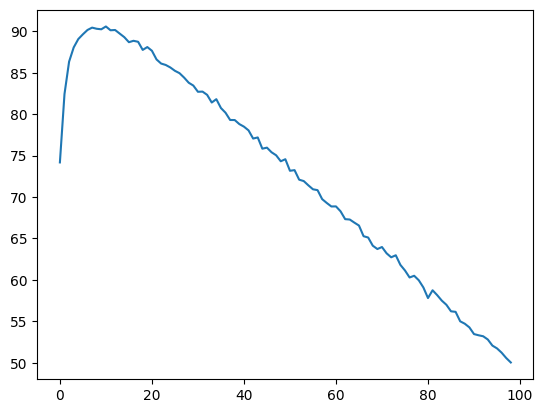

In [105]:
plt.plot(avg_picked)
plt.show()

## Explanation
The problem I solved differs from the original Secretary Problem. Since there the goal is finding the best, largest values, which is found, then it's 1, otherwise it's complete faliure. In that version, the expected output is 100 / e = 37 but mine is clearly less.

It is due to mine being focused on optimization, instead of only caring about whether I picked the absolute maximum, I am maximizing the expected numerical value of the selected item. This changes the structure completely because now intermediate values matter.
